# 02 — Construction et optimisation du moteur de prédiction


In [106]:
%pip install -q scikit-learn mlflow joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuration et reproductibilité


In [107]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

import joblib
import mlflow
import sklearn

In [108]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)

print("NumPy :", np.__version__)
print("Pandas :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("MLflow :", mlflow.__version__)
print("Seed :", SEED)

NumPy : 2.4.6
Pandas : 2.3.3
Scikit-learn : 1.9.0
MLflow : 3.14.0
Seed : 42


## 2. Chargement et contrôle du dataset


In [109]:
DATA_DIR = Path("data")

DATA_PATH = DATA_DIR / "consolidated_crop_yield.csv"

df = pd.read_csv(DATA_PATH)

print("Dimensions :", df.shape)
display(df.head())

Dimensions : (15193, 7)


,Area_std,Item,Year,rainfall_mm,pesticides_tonnes,avg_temp,yield_t_ha
0,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
1,Albania,Maize,1991,1485.0,121.0,15.36,2.9068
2,Albania,Maize,1992,1485.0,121.0,16.06,2.4876
3,Albania,Maize,1993,1485.0,121.0,16.05,2.4185
4,Albania,Maize,1994,1485.0,201.0,16.96,2.5848


In [110]:
dataset_checks = {
    "15193_rows": len(df) == 15193,
    "7_columns": df.shape[1] == 7,
    "no_missing": df.isna().sum().sum() == 0,
    "no_duplicates": df.duplicated().sum() == 0,
    "unique_key": (
        df.duplicated(
            ["Area_std", "Item", "Year"]
        ).sum() == 0
    ),
    "114_areas": df["Area_std"].nunique() == 114,
    "10_items": df["Item"].nunique() == 10,
    "23_years": df["Year"].nunique() == 23,
    "positive_target": (df["yield_t_ha"] > 0).all()
}

dataset_checks

{'15193_rows': True,
 '7_columns': True,
 'no_missing': np.True_,
 'no_duplicates': np.True_,
 'unique_key': np.True_,
 '114_areas': True,
 '10_items': True,
 '23_years': True,
 'positive_target': np.True_}

In [111]:
assert all(dataset_checks.values())

print("Dataset prêt pour la modélisation.")

Dataset prêt pour la modélisation.


## 3. Définition de X et y


In [112]:
TARGET = "yield_t_ha"

FEATURES = [
    "Area_std",
    "Item",
    "Year",
    "rainfall_mm",
    "pesticides_tonnes",
    "avg_temp"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("X :", X.shape)
print("y :", y.shape)

display(X.head())
display(y.head())

X : (15193, 6)
y : (15193,)


,Area_std,Item,Year,rainfall_mm,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,1485.0,121.0,16.37
1,Albania,Maize,1991,1485.0,121.0,15.36
2,Albania,Maize,1992,1485.0,121.0,16.06
3,Albania,Maize,1993,1485.0,121.0,16.05
4,Albania,Maize,1994,1485.0,201.0,16.96


0    3.6613
1    2.9068
2    2.4876
3    2.4185
4    2.5848
Name: yield_t_ha, dtype: float64

In [113]:
categorical_features = [
    "Area_std",
    "Item"
]

numeric_features = [
    "Year",
    "rainfall_mm",
    "pesticides_tonnes",
    "avg_temp"
]

print("Catégorielles :", categorical_features)
print("Numériques :", numeric_features)

Catégorielles : ['Area_std', 'Item']
Numériques : ['Year', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']


In [114]:
assert TARGET not in X.columns
assert len(X) == len(y)
assert set(FEATURES) == set(
    categorical_features + numeric_features
)

print("Définition X / y validée.")

Définition X / y validée.


## 4. Stratégie de validation et découpage des données


      DONNÉES
       │
       ├── TRAIN
         │     │
         │     └── validation / cross-validation
         │           ↓
         │       choix du modèle
         │       hyperparamètres
         │
         └── TEST FINAL
                   ↓
             une seule évaluation
             à la fin

In [115]:
train_test_split(X, y, random_state=42)

[           Area_std         Item  Year  rainfall_mm  pesticides_tonnes  \
 5549         Guyana  Rice, paddy  1993       2387.0             289.90   
 5769          Haiti         Yams  1997       1440.0              16.35   
 12248  South Africa     Soybeans  2004        495.0           26857.00   
 3946        Ecuador  Rice, paddy  2007       2274.0           14156.16   
 4336    El Salvador      Sorghum  2006       1784.0            2265.72   
 ...             ...          ...   ...          ...                ...   
 5191      Guatemala     Potatoes  2011       1996.0           16540.71   
 13418        Turkey        Maize  2008        593.0           37640.20   
 5390         Guinea  Rice, paddy  1995       1651.0             153.00   
 860         Austria        Wheat  1992       1110.0            3897.00   
 7270     Kazakhstan     Potatoes  2011        250.0           10656.60   
 
        avg_temp  
 5549     26.950  
 5769     27.740  
 12248    18.450  
 3946     20.370  
 43

### 4.1 Jeu de test temporel
- Le jeu de test est constitué des dernières années disponibles afin de simuler une prédiction sur des observations temporellement postérieures aux données utilisées pour l'entraînement.
- Le jeu de test final restera isolé pendant la comparaison etl'optimisation des modèles.

In [116]:
TEST_START_YEAR = 2010

train_mask = df["Year"] < TEST_START_YEAR
test_mask = df["Year"] >= TEST_START_YEAR

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train :", X_train.shape)
print("Test :", X_test.shape)

print(
    "Années train :",
    X_train["Year"].min(),
    "→",
    X_train["Year"].max()
)

print(
    "Années test :",
    X_test["Year"].min(),
    "→",
    X_test["Year"].max()
)

Train : (12470, 6)
Test : (2723, 6)
Années train : 1990 → 2009
Années test : 2010 → 2013


In [117]:
TEST_START_YEAR = 2010

train_mask = df["Year"] < TEST_START_YEAR
test_mask = df["Year"] >= TEST_START_YEAR

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train :", X_train.shape)
print("Test :", X_test.shape)

print(
    "Années train :",
    X_train["Year"].min(),
    "→",
    X_train["Year"].max()
)

print(
    "Années test :",
    X_test["Year"].min(),
    "→",
    X_test["Year"].max()
)

Train : (12470, 6)
Test : (2723, 6)
Années train : 1990 → 2009
Années test : 2010 → 2013


In [118]:
print(
    "Cultures absentes du train :",
    sorted(
        set(X_test["Item"])
        - set(X_train["Item"])
    )
)

print(
    "Zones du test absentes du train :",
    sorted(
        set(X_test["Area_std"])
        - set(X_train["Area_std"])
    )
)

Cultures absentes du train : []
Zones du test absentes du train : ['Sudan']


## 5. Pipeline de preprocessing


- `Area_std` et `Item` : One-Hot Encoding.
- `Year`, `rainfall_mm` et `avg_temp` : standardisation.
- `pesticides_tonnes` : transformation `log1p` puis standardisation.

In [119]:
#Split features 

categorical_features = [
    "Area_std",
    "Item"
]

numeric_features = [
    "Year",
    "rainfall_mm",
    "avg_temp"
]

pesticides_feature = [
    "pesticides_tonnes"
]

In [120]:
# Pipeline de transformation des variables catégorielles

categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Pipeline de transformation des variables numériques
numeric_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Pipleine de transformation de la variable pesticides_tonnes
pesticides_pipeline = Pipeline(
    steps=[
        (
            "log1p",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [121]:
# Assemblage des pipelines dans un ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "pesticides",
            pesticides_pipeline,
            pesticides_feature
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [122]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

X_test_transformed = preprocessor.transform(
    X_test
)

print(
    "Train avant preprocessing :",
    X_train.shape
)

print(
    "Train après preprocessing :",
    X_train_transformed.shape
)

print(
    "Test après preprocessing :",
    X_test_transformed.shape
)

print(
    "NaN train transformé :",
    np.isnan(X_train_transformed).sum()
)

print(
    "NaN test transformé :",
    np.isnan(X_test_transformed).sum()
)

Train avant preprocessing : (12470, 6)
Train après preprocessing : (12470, 127)
Test après preprocessing : (2723, 127)


NaN train transformé : 0
NaN test transformé : 0


In [123]:
# Récupération des features après preprocessing
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Nombre de features après preprocessing :",
    len(feature_names)
)

print("\n20 premières :")

for name in feature_names[:20]:
    print(name)

Nombre de features après preprocessing : 127

20 premières :
categorical__Area_std_Albania
categorical__Area_std_Algeria
categorical__Area_std_Angola
categorical__Area_std_Argentina
categorical__Area_std_Armenia
categorical__Area_std_Australia
categorical__Area_std_Austria
categorical__Area_std_Azerbaijan
categorical__Area_std_Bahamas
categorical__Area_std_Bahrain
categorical__Area_std_Bangladesh
categorical__Area_std_Belarus
categorical__Area_std_Belgium
categorical__Area_std_Bolivia (Plurinational State of)
categorical__Area_std_Botswana
categorical__Area_std_Brazil
categorical__Area_std_Bulgaria
categorical__Area_std_Burkina Faso
categorical__Area_std_Burundi
categorical__Area_std_Cameroon


### Conclusion du preprocessing

- Le jeu d'entraînement contient **12 470 observations** et le jeu de test **2 723 observations**.
- Après preprocessing, les 6 variables initiales sont représentées par **127 features**.
- Le nombre de features est identique entre les jeux d'entraînement et de test.
- Aucun NaN n'est généré par les transformations.
- Les variables catégorielles sont encodées avec gestion des catégories inconnues.
- Les variables numériques sont standardisées.
- `pesticides_tonnes` subit une transformation logarithmique avant standardisation.
- Le preprocessing est appris exclusivement sur le jeu d'entraînement afin d'éviter toute fuite de données.

## 6. Modèle baseline


### 6.1 Fonction d'évaluation

In [124]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### 6.2 Baseline (DummyRegressor)

In [125]:
# Pipeline de base avec DummyRegressor
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyRegressor(
                strategy="mean"
            )
        )
    ]
)

In [126]:
# Entraînement du pipeline de base

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_pred = baseline_pipeline.predict(
    X_test
)

In [127]:
# Évaluation du modèle de base

baseline_metrics = evaluate_regression(
    y_test,
    baseline_pred
)

baseline_metrics

{'MAE': 6.015433039792011,
 'RMSE': np.float64(8.661233754002573),
 'R2': -0.019793140332319048}

In [128]:
baseline_results = pd.DataFrame(
    [baseline_metrics],
    index=["DummyRegressor"]
)

display(
    baseline_results.round(3)
)

,MAE,RMSE,R2
DummyRegressor,6.015,8.661,-0.02


In [129]:
# Comparaison des rendements moyens du train, du test et de la prédiction constante baseline

print(
    "Rendement moyen du train :",
    round(y_train.mean(), 3),
    "t/ha"
)

print(
    "Rendement moyen du test :",
    round(y_test.mean(), 3),
    "t/ha"
)

print(
    "Prédiction constante baseline :",
    round(baseline_pred[0], 3),
    "t/ha"
)

Rendement moyen du train : 6.718 t/ha
Rendement moyen du test : 7.925 t/ha
Prédiction constante baseline : 6.718 t/ha


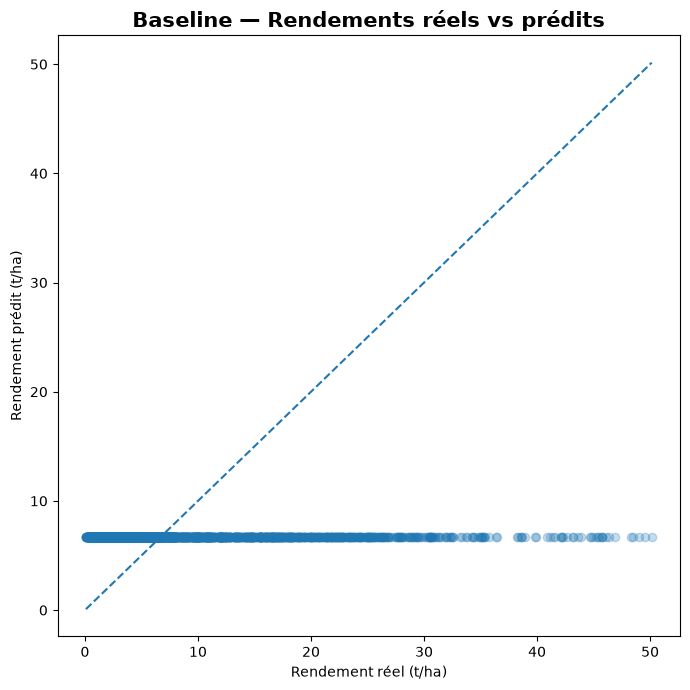

In [130]:
# Visualisation des rendements réels vs prédits par le modèle baseline

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    baseline_pred,
    alpha=0.25
)

min_val = min(
    y_test.min(),
    baseline_pred.min()
)

max_val = max(
    y_test.max(),
    baseline_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Rendement réel (t/ha)")
plt.ylabel("Rendement prédit (t/ha)")

plt.title(
    "Baseline — Rendements réels vs prédits",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
#plt.show()

In [131]:
# Stockage des résultats du modèle baseline dans un DataFrame

model_results = pd.DataFrame([
    {
        "Model": "DummyRegressor",
        **baseline_metrics
    }
])

display(
    model_results.round(3)
)

,Model,MAE,RMSE,R2
0,DummyRegressor,6.015,8.661,-0.02


### Conclusion — Baseline

Le `DummyRegressor` prédit systématiquement le rendement moyen observé
sur le jeu d'entraînement, soit **6,718 t/ha**.

Sur la période de test 2010–2013 :

- rendement moyen réel : **7,925 t/ha** ;
- MAE : **6,015 t/ha** ;
- RMSE : **8,661 t/ha** ;
- R² : **-0,020**.

Le rendement moyen du jeu de test est supérieur d'environ **1,21 t/ha**
à celui du jeu d'entraînement. Ce décalage confirme l'intérêt du découpage
temporel : les données futures ne suivent pas exactement la même distribution
que les données historiques.

La baseline n'explique pas la variabilité des rendements puisqu'elle produit
une prédiction identique pour toutes les observations. Elle constitue donc
notre niveau de référence pour mesurer l'apport des modèles supervisés.

## 7. Comparaison de plusieurs modèles


### 7.1 Validation temporelle interne

- Les modèles sont comparés à l'aide d'une validation temporelle en fenêtre
expansive :  Pour chaque fold, l'entraînement utilise uniquement des années antérieures à l'année de validation.

- Le jeu de test final 2010–2013 reste totalement isolé pendant cette étape.

In [132]:
validation_years = [
    2006,
    2007,
    2008,
    2009
]

temporal_cv = []

for validation_year in validation_years:

    train_idx = np.where(
        X_train["Year"].to_numpy()
        < validation_year
    )[0]

    valid_idx = np.where(
        X_train["Year"].to_numpy()
        == validation_year
    )[0]

    temporal_cv.append(
        (train_idx, valid_idx)
    )

    print(
        f"Validation {validation_year} | "
        f"Train = {len(train_idx)} | "
        f"Validation = {len(valid_idx)}"
    )

Validation 2006 | Train = 9773 | Validation = 674
Validation 2007 | Train = 10447 | Validation = 673
Validation 2008 | Train = 11120 | Validation = 676
Validation 2009 | Train = 11796 | Validation = 674


In [133]:
for i, (train_idx, valid_idx) in enumerate(
    temporal_cv,
    start=1
):

    max_train_year = (
        X_train
        .iloc[train_idx]["Year"]
        .max()
    )

    min_valid_year = (
        X_train
        .iloc[valid_idx]["Year"]
        .min()
    )

    max_valid_year = (
        X_train
        .iloc[valid_idx]["Year"]
        .max()
    )

    print(
        f"Fold {i} : "
        f"train <= {max_train_year} | "
        f"validation = {min_valid_year}-{max_valid_year}"
    )

    assert max_train_year < min_valid_year

print(
    "\nValidation temporelle interne validée."
)

Fold 1 : train <= 2005 | validation = 2006-2006
Fold 2 : train <= 2006 | validation = 2007-2007
Fold 3 : train <= 2007 | validation = 2008-2008
Fold 4 : train <= 2008 | validation = 2009-2009

Validation temporelle interne validée.


### 7.2 Définition des modèles

- Ridge : Modèle linéaire régularisé
- RandomForestRegressor :  Relations non linéaires
- HistGradientBoostingRegressor : arbres itératifs avec boosting 


In [134]:
models = {
    
    "DummyRegressor": DummyRegressor(
        strategy="mean"
    ),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=SEED
    )
}

### 7.2 Comparaison des modèles (avec validation temporelle)


In [135]:
comparison_results = []

for model_name, model in models.items():

    print(f"\n--- {model_name} ---")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=temporal_cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=1,
        return_train_score=False
    )

    mean_mae = -scores["test_MAE"].mean()
    std_mae = scores["test_MAE"].std()

    mean_rmse = -scores["test_RMSE"].mean()
    std_rmse = scores["test_RMSE"].std()

    mean_r2 = scores["test_R2"].mean()
    std_r2 = scores["test_R2"].std()

    comparison_results.append({
        "Model": model_name,
        "MAE_mean": mean_mae,
        "MAE_std": std_mae,
        "RMSE_mean": mean_rmse,
        "RMSE_std": std_rmse,
        "R2_mean": mean_r2,
        "R2_std": std_r2
    })


--- DummyRegressor ---

--- Ridge ---

--- RandomForest ---

--- HistGradientBoosting ---


In [136]:
comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.sort_values(
    "RMSE_mean"
).reset_index(drop=True)

display(
    comparison_df.round(3)
)

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,RandomForest,0.796,0.024,1.586,0.092,0.962,0.005
1,HistGradientBoosting,1.611,0.070,2.579,0.169,0.901,0.007
2,Ridge,2.909,0.096,4.350,0.228,0.719,0.010
3,DummyRegressor,5.775,0.153,8.248,0.303,-0.012,0.003


### Conclusion — Comparaison initiale des modèles

Quatre modèles ont été comparés à l'aide d'une validation temporelle
en fenêtre expansive sur les données d'entraînement.

Le `RandomForestRegressor` obtient les meilleures performances moyennes :

- **MAE : 0,796 t/ha**
- **RMSE : 1,586 t/ha**
- **R² : 0,962**

Il présente également une faible variabilité entre les folds
(RMSE ± 0,092 ; R² ± 0,005), indiquant des performances relativement
stables sur les années de validation considérées.

`HistGradientBoostingRegressor` arrive ensuite avec un RMSE de
2,579 t/ha, tandis que le modèle linéaire Ridge obtient un RMSE
de 4,350 t/ha.

L'écart entre Ridge et les modèles à base d'arbres suggère que les
relations entre les caractéristiques et le rendement comportent des
non-linéarités et/ou interactions importantes.

Le Random Forest est retenu comme **candidat prioritaire à
l'optimisation des hyperparamètres**. Le jeu de test final 2010–2013
reste isolé et n'a pas été utilisé pour cette sélection.

## 8. Optimisation du meilleur modèle


- Le **Random Forest** ayant obtenu les meilleures performances lors de la
comparaison initiale, il est retenu comme candidat à l'optimisation.

- L'optimisation est réalisée exclusivement sur le jeu **Train** à
l'aide des mêmes **folds temporels** que lors de la comparaison des modèles.

- Le jeu de test 2010–2013 reste isolé.

### 8.1 Pipeline


In [137]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Pipeline à optimiser avec RandomizedSearchCV

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

### 8.2 Hyperparamètres


In [139]:
# Hyperparamètres à tester pour RandomizedSearchCV

param_distributions = {

    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30,
        40
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        0.5,
        0.75,
        1.0
    ]
}

### 8.3 Execution de la CV


In [140]:
# Configuration de RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv,
    random_state=SEED,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [141]:
# Entraînement de RandomizedSearchCV sur les données d'entraînement

random_search.fit(
    X_train,
    y_train
)

Fitting 4 folds for each of 30 candidates, totalling 120 fits
[CV] END model__max_depth=40, model__max_features=0.75, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=40, model__max_features=0.75, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=40, model__max_features=0.75, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=40, model__max_features=0.75, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=20, model__max_features=0.75, model__min_samples_leaf=2, model__min_samples_split=20, model__n_estimators=200; total time=   0.7s
[CV] END model__max_depth=20, model__max_features=0.75, model__min_samples_leaf=2, model__min_samples_split=20, model__n_estimators=200; total time=   0.7s
[CV] E

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': [0.5, 0.75, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0,...shape=(9773,)), ...), (array([ 0,...hape=(10447,)), ...), ...]"
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However comput

In [145]:


search_results = pd.DataFrame(
    random_search.cv_results_
)

top_configs = (
    search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

top_configs["RMSE_validation"] = (
    -top_configs["mean_test_score"]
)

top_configs["RMSE_train"] = (
    -top_configs["mean_train_score"]
)

display(
    top_configs[
        [
            "rank_test_score",
            "RMSE_train",
            "RMSE_validation",
            "std_test_score",
            "params"
        ]
    ].round(3)
)

,rank_test_score,RMSE_train,RMSE_validation,std_test_score,params
11,1,0.441,1.621,0.087,"{'model__n_estimators': 500, 'model__min_sampl..."
10,2,0.461,1.665,0.088,"{'model__n_estimators': 100, 'model__min_sampl..."
29,3,0.609,1.665,0.076,"{'model__n_estimators': 300, 'model__min_sampl..."
0,4,0.615,1.666,0.077,"{'model__n_estimators': 100, 'model__min_sampl..."
24,5,0.657,1.674,0.081,"{'model__n_estimators': 100, 'model__min_sampl..."
20,6,0.652,1.679,0.077,"{'model__n_estimators': 200, 'model__min_sampl..."
14,7,0.650,1.725,0.076,"{'model__n_estimators': 300, 'model__min_sampl..."
8,8,0.707,1.736,0.068,"{'model__n_estimators': 300, 'model__min_sampl..."
17,9,0.729,1.737,0.077,"{'model__n_estimators': 100, 'model__min_sampl..."
18,10,0.718,1.771,0.063,"{'model__n_estimators': 200, 'model__min_sampl..."


In [142]:
# Récupération des meilleurs hyperparamètres et du meilleur score

print(
    "Meilleur RMSE CV :",
    round(
        -random_search.best_score_,
        3
    ),
    "t/ha"
)

print(
    "\nMeilleurs hyperparamètres :"
)

for param, value in random_search.best_params_.items():
    print(
        f"{param.replace('model__', '')}: {value}"
    )

Meilleur RMSE CV : 1.621 t/ha

Meilleurs hyperparamètres :
n_estimators: 500
min_samples_split: 2
min_samples_leaf: 1
max_features: 0.75
max_depth: None


In [143]:
# Récupération du meilleur pipeline entraîné

best_rf_pipeline = random_search.best_estimator_

### 8.4 Comparaison avant / après optimisation des hyperparamètres


In [144]:
initial_rf_rmse = (
    comparison_df
    .loc[
        comparison_df["Model"] == "RandomForest",
        "RMSE_mean"
    ]
    .iloc[0]
)

optimized_rf_rmse = -random_search.best_score_

improvement_pct = (
    (initial_rf_rmse - optimized_rf_rmse)
    / initial_rf_rmse
    * 100
)

print(
    "Random Forest initial :",
    round(initial_rf_rmse, 3),
    "t/ha"
)

print(
    "Random Forest optimisé :",
    round(optimized_rf_rmse, 3),
    "t/ha"
)

print(
    "Amélioration RMSE :",
    round(improvement_pct, 2),
    "%"
)

Random Forest initial : 1.586 t/ha
Random Forest optimisé : 1.621 t/ha
Amélioration RMSE : -2.22 %


### Conclusion — Optimisation des hyperparamètres

Une recherche aléatoire de 30 configurations du `RandomForestRegressor`
a été réalisée à l'aide des mêmes folds de validation temporelle.

La meilleure configuration explorée est :

- `n_estimators = 500`
- `max_depth = None`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = 0.75`

Elle obtient un **RMSE moyen de 1,621 t/ha**, contre **1,586 t/ha**
pour la configuration initiale.

L'optimisation n'apporte donc pas d'amélioration : le RMSE augmente
d'environ **2,22 %**.

Ce résultat montre que l'optimisation d'hyperparamètres ne garantit pas
une amélioration des performances. La configuration initiale reste à ce
stade le candidat privilégié, sous réserve de la comparaison finale
effectuée avec exactement le même protocole de validation.


**La configuration retenue pour la suite est donc :**

- `n_estimators = 200`
- `random_state = 42`
- autres hyperparamètres laissés à leurs valeurs par défaut.

Le modèle n'est pas choisi sur ses performances d'entraînement mais sur
ses performances moyennes en validation temporelle.


## 9. Suivi des expériences avec MLflow


In [150]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment(
    "crop_yield_prediction"
)

2026/09/23 10:45:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/23 10:45:31 INFO mlflow.store.db.utils: Updating database tables
2026/09/23 10:45:32 INFO mlflow.tracking.fluent: Experiment with name 'crop_yield_prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///c:/Users/obenb/Formation data scientist machine learning eng/Projet '
 '12-/mlruns/1'), creation_time=1790153132247, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790153132247, lifecycle_stage='active', name='crop_yield_prediction', tags={}, trace_location=None, workspace='default'>

In [158]:
from pathlib import Path
import mlflow
import mlflow.sklearn

MLFLOW_DB = (Path.cwd() / "mlflow.db").resolve()

TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"

mlflow.set_tracking_uri(TRACKING_URI)

print(
    "Tracking URI :",
    mlflow.get_tracking_uri()
)

mlflow.set_experiment(
    "crop_yield_prediction"
)

print(
    "Base MLflow existe :",
    MLFLOW_DB.exists()
)

2026/09/23 10:57:19 INFO mlflow.tracking.fluent: Experiment with name 'crop_yield_prediction' does not exist. Creating a new experiment.


Tracking URI : sqlite:///C:/Users/obenb/Formation data scientist machine learning eng/Projet 12-/mlflow.db
Base MLflow existe : True


In [159]:
experiment = mlflow.get_experiment_by_name(
    "crop_yield_prediction"
)

print(
    "Nom :",
    experiment.name
)

print(
    "Experiment ID :",
    experiment.experiment_id
)

print(
    "Artifact location :",
    experiment.artifact_location
)

Nom : crop_yield_prediction
Experiment ID : 1
Artifact location : file:///c:/Users/obenb/Formation data scientist machine learning eng/Projet 12-/mlruns/1


In [ ]:
# modèles dans MLflow

mlflow_models = {

    "DummyRegressor": DummyRegressor(
        strategy="mean"
    ),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=SEED
    )
}

In [152]:
mlflow_models["RandomForest_tuned"] = RandomForestRegressor(
    **tuned_params,
    random_state=SEED,
    n_jobs=-1
)

In [160]:
# expériences dans MLflow

from sklearn.base import clone

mlflow_results = []

for model_name, model in mlflow_models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            model
        )
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=temporal_cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=1
    )

    mae_mean = -scores["test_MAE"].mean()
    mae_std = scores["test_MAE"].std()

    rmse_mean = -scores["test_RMSE"].mean()
    rmse_std = scores["test_RMSE"].std()

    r2_mean = scores["test_R2"].mean()
    r2_std = scores["test_R2"].std()

    with mlflow.start_run(
        run_name=model_name
    ):

        # Informations générales
        mlflow.set_tag(
            "model_name",
            model_name
        )

        mlflow.set_tag(
            "validation_strategy",
            "temporal_expanding_window"
        )

        mlflow.set_tag(
            "dataset",
            "consolidated_crop_yield"
        )

        mlflow.set_tag(
            "test_status",
            "not_used"
        )

        # Paramètres communs
        mlflow.log_param(
            "seed",
            SEED
        )

        mlflow.log_param(
            "n_temporal_folds",
            len(temporal_cv)
        )

        # Hyperparamètres du modèle
        for param, value in model.get_params().items():
            mlflow.log_param(
                param,
                value
            )

        # Métriques
        mlflow.log_metric(
            "MAE_mean",
            mae_mean
        )

        mlflow.log_metric(
            "MAE_std",
            mae_std
        )

        mlflow.log_metric(
            "RMSE_mean",
            rmse_mean
        )

        mlflow.log_metric(
            "RMSE_std",
            rmse_std
        )

        mlflow.log_metric(
            "R2_mean",
            r2_mean
        )

        mlflow.log_metric(
            "R2_std",
            r2_std
        )

        mlflow_results.append({
            "Model": model_name,
            "MAE": mae_mean,
            "RMSE": rmse_mean,
            "R2": r2_mean
        })

In [154]:
# Stockage des résultats dans un DataFrame

mlflow_results_df = (
    pd.DataFrame(mlflow_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    mlflow_results_df.round(3)
)

,Model,MAE,RMSE,R2
0,RandomForest,0.796,1.586,0.962
1,RandomForest_tuned,0.812,1.621,0.961
2,HistGradientBoosting,1.611,2.579,0.901
3,Ridge,2.909,4.350,0.719
4,DummyRegressor,5.775,8.248,-0.012


## 10. Evaluation finale sur le jeu de test


### 10.1 Entrainement 


In [162]:
# Pipeline retenu 

from sklearn.base import clone

final_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [163]:
# Entrainement sur l'intégralité du train dispo avant 2010 

final_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Area_std','Item','Year','rainfall_mm','pesticides_tonnes','avg_temp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This su

In [164]:
# Evaluation finale sur le test set (2010-2012)

y_test_pred = final_pipeline.predict(
    X_test
)

final_test_metrics = evaluate_regression(
    y_test,
    y_test_pred
)

final_test_metrics

{'MAE': 1.14653233749541,
 'RMSE': np.float64(2.333603082455949),
 'R2': 0.925970205054682}

In [165]:
# Affichage

print(
    "MAE test :",
    round(final_test_metrics["MAE"], 3),
    "t/ha"
)

print(
    "RMSE test :",
    round(final_test_metrics["RMSE"], 3),
    "t/ha"
)

print(
    "R² test :",
    round(final_test_metrics["R2"], 3)
)

MAE test : 1.147 t/ha
RMSE test : 2.334 t/ha
R² test : 0.926


### 10.2 Comparaison validation VS Test 


In [166]:
rf_cv = (
    comparison_df
    .loc[
        comparison_df["Model"] == "RandomForest"
    ]
    .iloc[0]
)

generalization_comparison = pd.DataFrame([
    {
        "Evaluation": "Validation temporelle",
        "MAE": rf_cv["MAE_mean"],
        "RMSE": rf_cv["RMSE_mean"],
        "R2": rf_cv["R2_mean"]
    },
    {
        "Evaluation": "Test final 2010-2013",
        "MAE": final_test_metrics["MAE"],
        "RMSE": final_test_metrics["RMSE"],
        "R2": final_test_metrics["R2"]
    }
])

display(
    generalization_comparison.round(3)
)

,Evaluation,MAE,RMSE,R2
0,Validation temporelle,0.796,1.586,0.962
1,Test final 2010-2013,1.147,2.334,0.926


### Conclusion — Évaluation finale

le pipeline Random Forest retenu a été évalué une seule fois sur le jeu de test final 2010–2013.

Les performances obtenues sont :

- **MAE : 1,147 t/ha**
- **RMSE : 2,334 t/ha**
- **R² : 0,926**

Observations :
- Les performances sont inférieures à celles observées lors de la validation (RMSE = 1,586 t/ha ; R² = 0,962).
    -  Le RMSE augmente d'environ 47 % => les années du test final sont plus difficiles à généraliser que les folds utilisés lors de la sélection du modèle.
- Malgré cette dégradation, le Random Forest reste très supérieur à la baseline sur le même jeu de test
    - Le RMSE était de 8,661 t/ha et le R² de -0,020.


Conclusions : 
- Capacité de généralisation importante
- Ecart entre les performances de validation et test 

## 11. Interprétation des variables importantes


Objectif : Sur quelles variables le Random Forest s'appuie-t-il pour produire ses prédictions ?

Contrainte : les 6 variables sont transformées en 127 features par le pipeline

solution : **permutation importance** pour conserver nos 6 variables 


### 11.1 Calcul de la permutation importance


In [167]:
from sklearn.inspection import permutation_importance

In [168]:
permutation_result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

In [169]:
importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df.round(3)
)

,Variable,Importance,Std
0,Item,8.188,0.151
1,avg_temp,2.804,0.122
2,rainfall_mm,2.651,0.129
3,pesticides_tonnes,2.179,0.137
4,Area_std,1.841,0.055
5,Year,0.000,0.000


### 11.2 Visualisation des variables


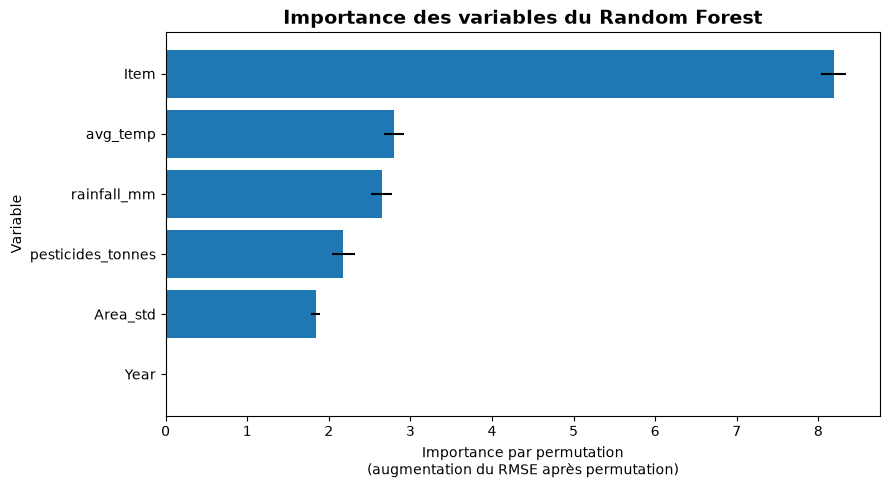

In [170]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Variable"],
    importance_df["Importance"],
    xerr=importance_df["Std"]
)

plt.gca().invert_yaxis()

plt.xlabel(
    "Importance par permutation\n"
    "(augmentation du RMSE après permutation)"
)

plt.ylabel("Variable")

plt.title(
    "Importance des variables du Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Conclusion — Importance des variables

- `Item` est la variable dominante : le rendement dépend fortement de la culture considérée.
- `avg_temp`, `rainfall_mm` et `pesticides_tonnes` contribuent également fortement aux prédictions.
- `Area_std` apporte une information géographique complémentaire.
- `Year` n'apporte aucune contribution mesurable sur le jeu de test.

Le modèle exploite donc à la fois la culture, les conditions agronomiques et climatiques et la zone géographique.

Ces importances sont **prédictives et non causales** : elles ne permettent pas de conclure qu'une modification d'une variable entraînerait directement une variation du rendement.

## 12. Moteur de recommandation


In [171]:
# Récupération des cultures disponibles dans le dataset

available_crops = sorted(
    df["Item"].unique()
)

print(
    "Nombre de cultures :",
    len(available_crops)
)

print(available_crops)

Nombre de cultures : 10
['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']


In [172]:
# Fonction de recommandation

def recommend_crops(
    area,
    year,
    rainfall_mm,
    pesticides_tonnes,
    avg_temp,
    model=final_pipeline
):
    """
    Classe les cultures selon leur rendement prédit
    pour un même contexte agronomique.
    """

    candidates = pd.DataFrame({
        "Area_std": [area] * len(available_crops),
        "Item": available_crops,
        "Year": [year] * len(available_crops),
        "rainfall_mm": [rainfall_mm] * len(available_crops),
        "pesticides_tonnes": [pesticides_tonnes] * len(available_crops),
        "avg_temp": [avg_temp] * len(available_crops)
    })

    predictions = model.predict(
        candidates
    )

    recommendations = pd.DataFrame({
        "Crop": available_crops,
        "Predicted_yield_t_ha": predictions
    })

    recommendations = (
        recommendations
        .sort_values(
            "Predicted_yield_t_ha",
            ascending=False
        )
        .reset_index(drop=True)
    )

    recommendations.index += 1
    recommendations.index.name = "Rank"

    return recommendations

In [173]:


example = X_test.iloc[0]

example

Area_std             Albania
Item                   Maize
Year                    2010
rainfall_mm           1485.0
pesticides_tonnes    1311.17
avg_temp               16.52
Name: 19, dtype: object

In [174]:
recommendations = recommend_crops(
    area=example["Area_std"],
    year=example["Year"],
    rainfall_mm=example["rainfall_mm"],
    pesticides_tonnes=example["pesticides_tonnes"],
    avg_temp=example["avg_temp"]
)

display(
    recommendations.round(3)
)

,Crop,Predicted_yield_t_ha
Rank,,
1,Potatoes,16.398
2,Sweet potatoes,11.420
3,Plantains and others,10.534
4,Cassava,7.924
5,Yams,6.592
6,"Rice, paddy",5.909
7,Maize,5.022
8,Sorghum,4.135
9,Wheat,3.727


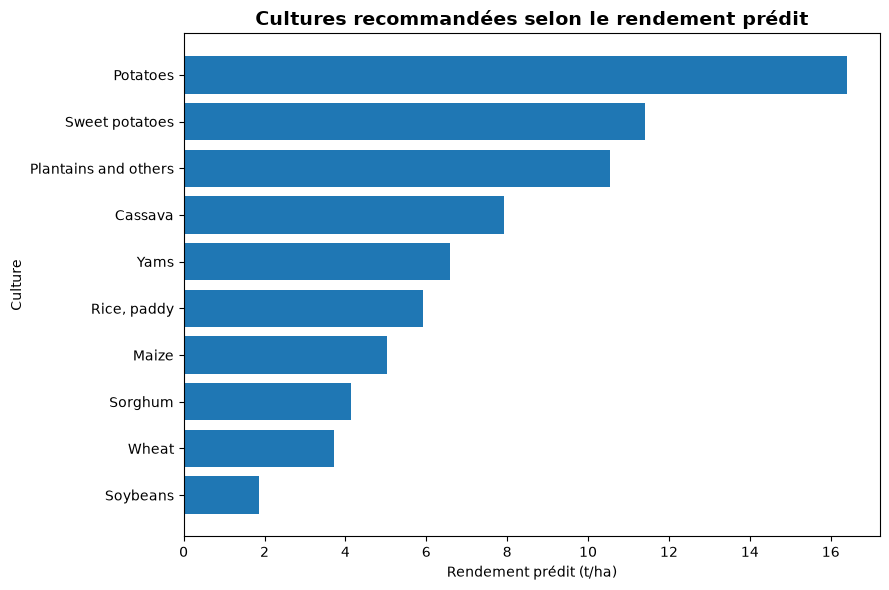

In [176]:
recommendations_plot = (
    recommendations
    .sort_values(
        "Predicted_yield_t_ha"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    recommendations_plot["Crop"],
    recommendations_plot["Predicted_yield_t_ha"]
)

plt.xlabel(
    "Rendement prédit (t/ha)"
)

plt.ylabel(
    "Culture"
)

plt.title(
    "Cultures recommandées selon le rendement prédit",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interprétation

Le moteur simule le rendement des 10 cultures pour un même contexte puis les classe par rendement prédit décroissant.

La première culture correspond donc au rendement prédit le plus élevé dans les conditions renseignées.

La recommandation porte uniquement sur le **rendement**. La rentabilité économique nécessiterait des données supplémentaires sur les prix et les coûts de production.

### Conclusion — Moteur de recommandation

Le moteur compare les 10 cultures pour un même contexte et les classe par rendement prédit.

Dans l'exemple testé, `Potatoes` obtient le rendement prédit le plus élevé, devant `Sweet potatoes` et `Plantains and others`.

Cette recommandation optimise uniquement le rendement prédit. Elle ne mesure pas la rentabilité économique, faute de données sur les prix et les coûts de production.

## 12. Pipeline final


In [177]:
# Enregistrement du pipeline final

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODELS_DIR / "crop_yield_pipeline.joblib"

In [178]:
# Enregistrement du pipeline final dans un fichier .joblib

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print(f"Modèle sauvegardé : {MODEL_PATH}")

Modèle sauvegardé : models\crop_yield_pipeline.joblib


### Sauvegarde du modèle

Pipeline final  sauvegardé avec `joblib`. Il contient le prétraitement et le Random Forest entraîné, ce qui permet son utilisation directe par l'API.

In [183]:
#Sauvegarde des métadonnées du modèle dans un fichier JSON



# Liste des cultures réellement connues pendant l'entraînement.
available_crops = sorted(
    X_train["Item"].unique().tolist()
)

# Liste des zones réellement connues pendant l'entraînement.
# Elles serviront notamment à limiter les choix proposés
# dans l'interface Streamlit.
available_areas = sorted(
    X_train["Area_std"].unique().tolist()
)


# Construction des métadonnées associées au modèle final.
metadata = {

    # Modèle utilisé pour la prédiction.
    "model": "RandomForestRegressor",

    # Variable cible prédite.
    "target": TARGET,

    # Variables utilisées en entrée du pipeline.
    "features": FEATURES,

    # Variables catégorielles encodées par le pipeline.
    "categorical_features": categorical_features,

    # Cultures connues pendant l'entraînement.
    "available_crops": available_crops,

    # Zones géographiques connues pendant l'entraînement.
    "available_areas": available_areas,

    # Période utilisée pour l'évaluation finale.
    "test_period": "2010-2013",

    # Performances obtenues sur le jeu de test final.
    "test_metrics": {
        "MAE": float(final_test_metrics["MAE"]),
        "RMSE": float(final_test_metrics["RMSE"]),
        "R2": float(final_test_metrics["R2"])
    }
}


# Chemin du fichier JSON contenant les métadonnées.
METADATA_PATH = MODELS_DIR / "model_metadata.json"


# Sauvegarde des métadonnées.
with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )


print(f"Métadonnées sauvegardées : {METADATA_PATH}")

Métadonnées sauvegardées : models\model_metadata.json


In [184]:
# ============================================================
# VÉRIFICATION DES MÉTADONNÉES SAUVEGARDÉES
# ============================================================

print(f"Nombre de cultures : {len(metadata['available_crops'])}")
print(f"Nombre de zones : {len(metadata['available_areas'])}")

print("\nCultures disponibles :")
print(metadata["available_crops"])

print("\nExemple de zones disponibles :")
print(metadata["available_areas"][:10])

Nombre de cultures : 10
Nombre de zones : 113

Cultures disponibles :
['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']

Exemple de zones disponibles :
['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain']


## 14. Synthèse de la modélisation

### Modèle retenu

Le Random Forest est le modèle retenu. Il obtient les meilleures performances lors de la validation temporelle parmi les modèles comparés.

L'optimisation des hyperparamètres n'a pas amélioré le RMSE. La configuration initiale a donc été conservée.

### Performances finales

Sur le jeu de test 2010–2013 :

- **MAE : 1,147 t/ha**
- **RMSE : 2,334 t/ha**
- **R² : 0,926**

Le modèle réduit fortement l'erreur par rapport à la baseline (RMSE : 8,661 t/ha).

### Variables importantes

`Item` est la variable la plus importante, suivie de `avg_temp`, `rainfall_mm`, `pesticides_tonnes` et `Area_std`.

`Year` n'apporte pas d'information prédictive mesurable sur le jeu de test.

Ces importances sont prédictives et ne démontrent pas de relations causales.

### Recommandation

Le moteur teste les 10 cultures pour un même contexte et les classe selon leur rendement prédit.

La recommandation optimise uniquement le **rendement**. La rentabilité économique ne peut pas être calculée avec les données disponibles, qui ne contiennent pas les prix de vente et coûts de production.

### Limites

- Les performances diminuent entre validation temporelle et test final.
- Une zone du test (`Sudan`) n'était pas présente dans l'entraînement.
- `Year` n'apporte pas d'information mesurable au modèle final.
- Les recommandations ne constituent pas des relations causales ni une optimisation économique.